🧠 Business Scenario

An automobile company wants to understand how engine size affects the price of a car.

From past observations, the product team believes:

For small engines, price increases slowly

For medium engines, price increases rapidly

For very large engines, price growth slows down due to luxury saturation

This indicates that the relationship between engine size and price is not strictly linear.

You are hired as a Data Analyst to analyze this pattern and build a model that can predict car prices accurately.
 
📝 Tasks

Load the dataset and identify the relevant columns.

Use:

Engine size as the input feature

Car price as the output variable

Visualize the relationship between engine size and price.

Build a predictive model to estimate car price based on engine size.

Predict the price for a car with:

Engine size = 200
 

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Importing the dataset
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [2]:
X = df[['enginesize']]
y = df['price']


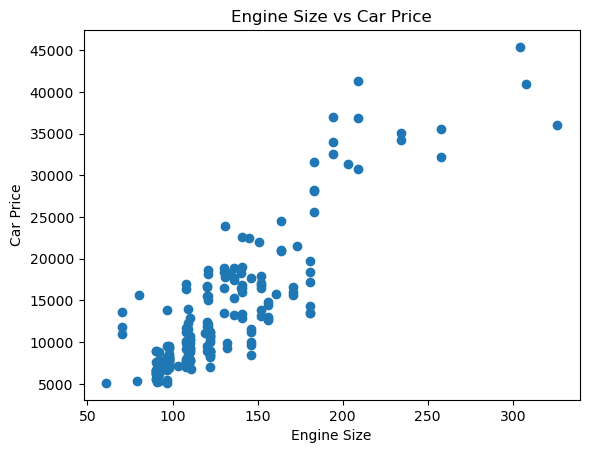

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Engine Size vs Car Price")
plt.show()


In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [7]:
model = LinearRegression()
model.fit(X_train_poly, y_train)


LinearRegression()

In [8]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test_poly)
print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: 0.8527894915155396


In [9]:
engine_size = [[200]]

engine_size_poly = poly.transform(engine_size)
predicted_price = model.predict(engine_size_poly)

predicted_price


c:\Users\chund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([27760.60834512])

c:\Users\chund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


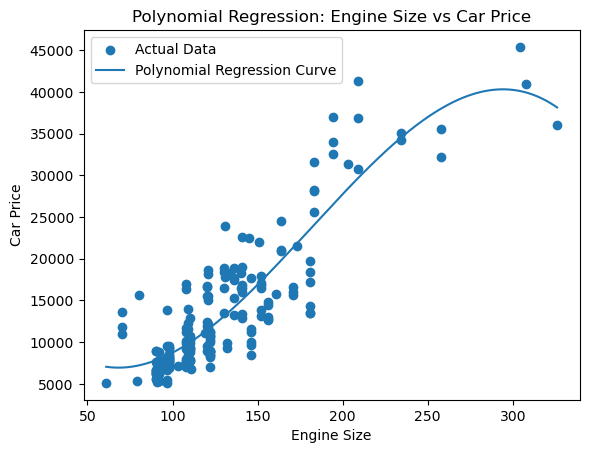

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Create smooth engine size range
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# Transform using polynomial features
X_range_poly = poly.transform(X_range)

# Predict prices
y_range_pred = model.predict(X_range_poly)

# Plot actual data
plt.scatter(X, y, label="Actual Data")

# Plot polynomial curve
plt.plot(X_range, y_range_pred, label="Polynomial Regression Curve")

plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Polynomial Regression: Engine Size vs Car Price")
plt.legend()
plt.show()


6.Increase the flexibility of your model and observe how the curve changes.

7.Compare predictions from:

a simple straight-line model

a curved model

8.Analyze which model:

captures the trend better

gives more realistic predictions

9.Evaluate prediction errors and interpret them in business terms.

10.Answer the following:

Why does a straight-line model fail here?

What risk occurs if the curve becomes too flexible?

Which model would you recommend for production and why?

c:\Users\chund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


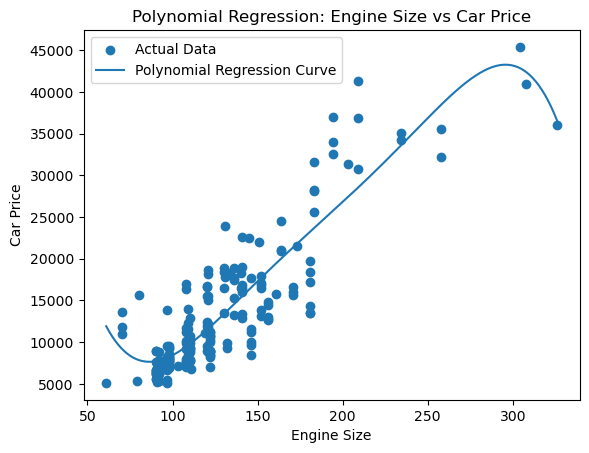

In [11]:
## Cheanging the flexibility by changing degree

poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model = LinearRegression()
model.fit(X_train_poly, y_train)
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# Transform using polynomial features
X_range_poly = poly.transform(X_range)

# Predict prices
y_range_pred = model.predict(X_range_poly)

# Plot actual data
plt.scatter(X, y, label="Actual Data")

# Plot polynomial curve
plt.plot(X_range, y_range_pred, label="Polynomial Regression Curve")

plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Polynomial Regression: Engine Size vs Car Price")
plt.legend()
plt.show()


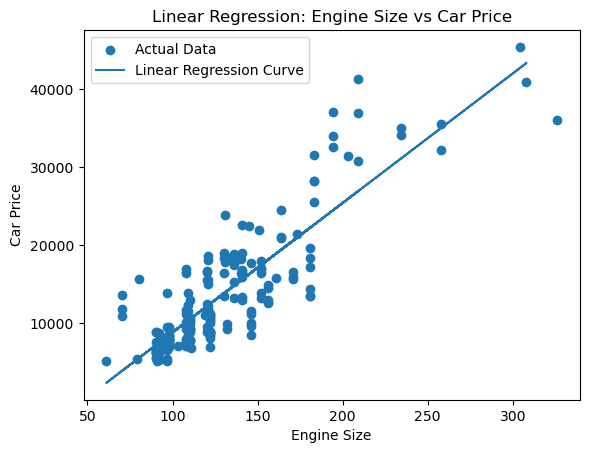

In [12]:
## Comparing linear and polynomial model
lin=LinearRegression()
lin.fit(X_train,y_train)
y_pred=lin.predict(X_test)
plt.scatter(X, y, label="Actual Data")

# Plot polynomial curve
plt.plot(X_test, y_pred, label="Linear Regression Curve")

plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Linear Regression: Engine Size vs Car Price")
plt.legend()
plt.show()


In [13]:
## Linear regression prediction
new_engiesize = np.array([[200]])
predicted_price= lin.predict(new_engiesize)
 
print("Predicted price for engine size 200:", predicted_price[0])

Predicted price for engine size 200: 25427.147445039867


c:\Users\chund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
### errors
from sklearn.metrics import mean_squared_error,r2_score
print('Error by linear regression:')
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2_score_value = r2_score(y_test, y_pred)
print("R² Score:", r2_score_value)

y_test_pred = model.predict(poly.transform(X_test))

mse = mean_squared_error(y_test, y_test_pred)
r2_score_value = r2_score(y_test, y_test_pred)

print("Error by Polynomial regression:")
print("Mean Squared Error:", mse)
print("R² Score:", r2_score_value)



Error by linear regression:
Mean Squared Error: 15465458.965908466
R² Score: 0.8040958796678975
Error by Polynomial regression:
Mean Squared Error: 13441339.921602
R² Score: 0.8297358080849215


### Polynomial Regression suits here because we get less error in polynomial when compared to linear regression model.When  polynomial model becomes too flexible it does not go through many data points.

In [15]:
# Prediction for one test value
test_value = [[200]]
test_prediction = lin.predict(test_value)

# Score
score = lin.score(X_test, y_test)

test_prediction, score


c:\Users\chund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


(array([25427.14744504]), 0.8040958796678975)

## Overfitting

In [16]:
import pandas as pd
df=pd.read_csv('CarPrice_Assignment.csv')


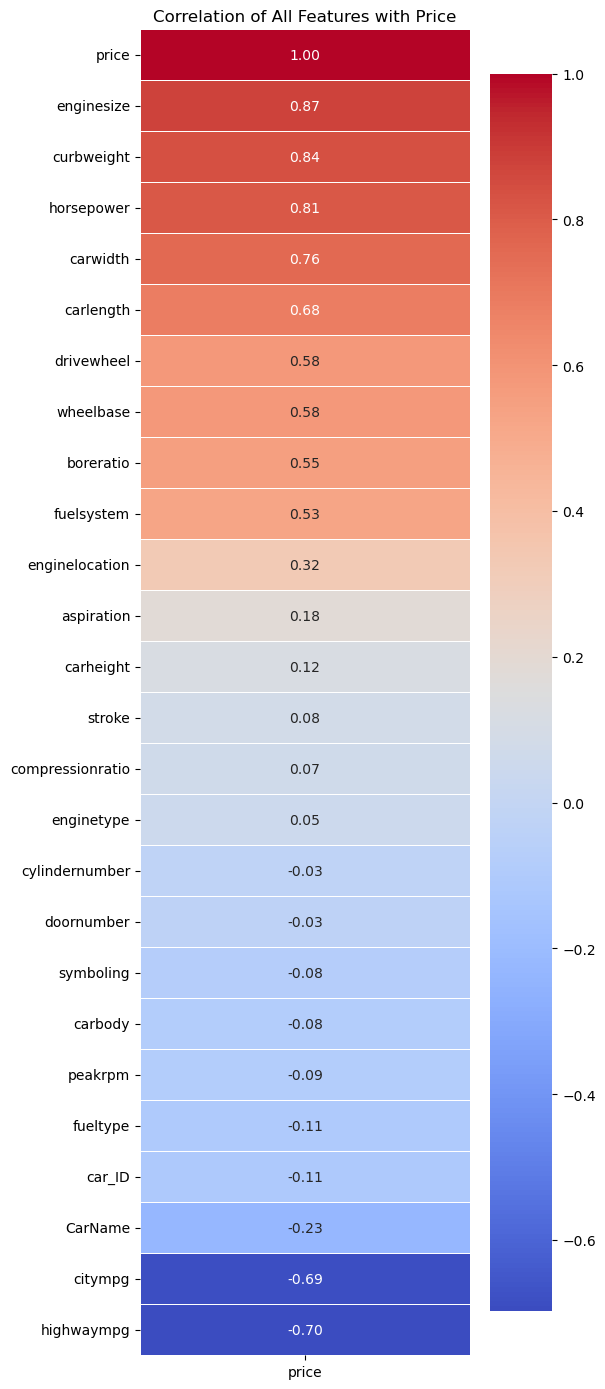

In [17]:
## Feature to target relationship 

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# encode all categorical columns
df_enc = df.copy()
le = LabelEncoder()
for c in df_enc.columns:
    if df_enc[c].dtype == 'object':
        df_enc[c] = le.fit_transform(df_enc[c])

# correlation of all features with price
price_corr = df_enc.corr()[['price']].sort_values(by='price', ascending=False)

# heatmap
plt.figure(figsize=(6, 14))
sns.heatmap(price_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of All Features with Price")
plt.tight_layout()
plt.show()


### Realtion with price(target)

highwaympg->strongly negative(-0.70)

citympg->strongly negative(-0.69)

carname->moderately negative(-0.23)

car_id->weakly negative(-0.11)

fueltype->weakly negative(-0.11)

peakrpm->weakly negative(-0.09)

carbody->weakly negative(-0.08)

symboling->weakly negative(-0.08)

doornumber->weakly negative(-0.03)

cylindernumber->weakly negative(-0.03)

enginetype->weakly positive(0.05)

compressionratio->weakly positive(0.07)

stroke->weakly positive(0.08)

carheight->weakly positive(0.12)

aspiration->weakly positive(0.18)

enginelocation->moderately positive(0.32)

fueltype->moderately positive(0.53)

boreratio->moderately positive(0.55)

wheelbase->moderately positive(0.58)

drivewheel->moderately positive(0.58)

carlength->moderately positive(0.68)

carwidth->strongly positive(0.76)

horsepower->strongly positive(0.81)

curbweight->strongly positive(0.84)

enginesize->strongly positive(0.87)


weakly negative:peakrpm,carbody,symboling,doornumber,cylindernumber

weakly positive:enginetype,compressionratio,stroke



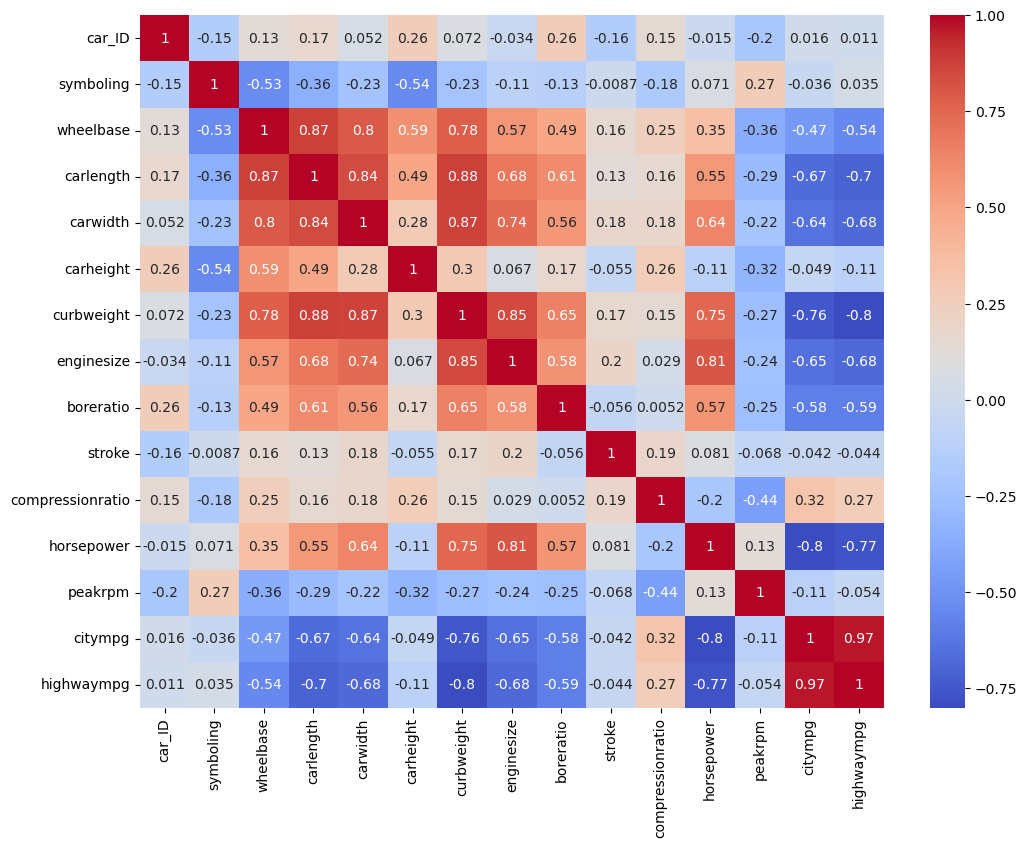

In [18]:
x=df.drop('price',axis=1)
 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,9))
sns.heatmap(x.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.show()

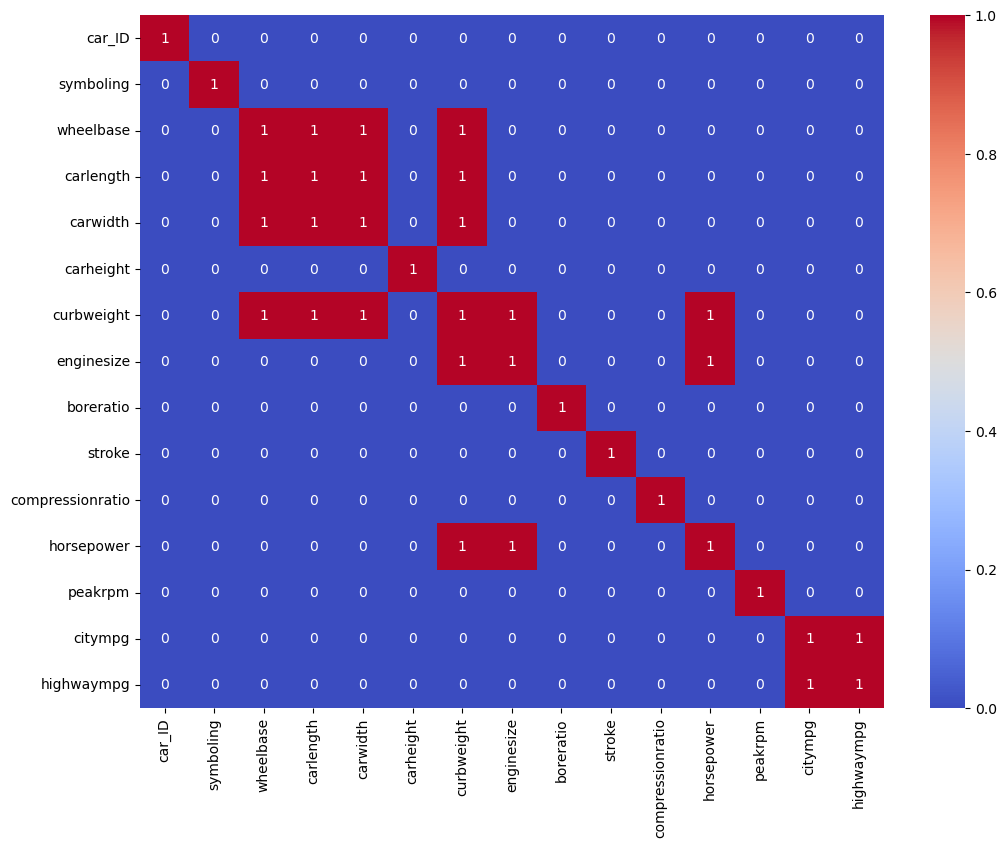

In [19]:
# Multicolinearity
x=df.drop('price',axis=1)
 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,9))
sns.heatmap(x.corr(numeric_only=True)>0.75, annot=True,cmap='coolwarm')
plt.show()

## Muticollinearity between features

wheelbase-->carlength(0.87)

wheelbase-->carwidth(0.8)

wheelbase-->curbweight(0.78)

carlength-->carwidth(0.84)

carlength-->curbweight(0.88)

carwidth-->curbweight(0.87)

curbweight-->enginesize(0.85)

curbweight-->horsepower(0.75)

enginesize-->horsepower(0.81)

citympg-->highwaympg(0.97)


In [20]:
### Remove features that have high multicollinearity and has less correlation with target to remove noise and columns with less correlation with price.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder


# copy dataframe
df_model = df.copy()

# encode categorical columns
le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

# drop specified columns
df_model.drop(
    columns=['doornumber', 'cylindernumber', 'enginetype', 'compressionratio', 'wheelbase'],
    inplace=True
)

# split features and target
X = df_model.drop('price', axis=1)
y = df_model['price']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# scores
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R² Score:", train_score)
print("Test R² Score:", test_score)




Train R² Score: 0.9036161653130529
Test R² Score: 0.8635871948799018


### Train the data using Ridge and Lasso

In [21]:
from sklearn.linear_model import RidgeCV

import numpy as np
alphas=np.arange(0.1,10,0.05)
model=RidgeCV(alphas=alphas)



model.fit(X_train, y_train)

print("Best alpha:", model.alpha_)

print("best score: ",model.score(X_test,y_test))
 

Best alpha: 0.15000000000000002
best score:  0.864316002517516


In [22]:
from sklearn.linear_model import LassoCV
import numpy as np

# alpha values
alphas = np.arange(0.1, 10, 0.05)

# Lasso model
model = LassoCV(alphas=alphas)
# Train
model.fit(X_train, y_train)

# Results
print("Best alpha:", model.alpha_)
print("Best score:", model.score(X_test, y_test))


Best alpha: 9.950000000000003
Best score: 0.8652471729829355
